In [1]:
# import modules
import datacube
import joblib
import numpy as np
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap
from dea_tools.classification import sklearn_flatten, sklearn_unflatten 
from dea_tools.datahandling import load_ard
from dea_tools.plotting import display_map, rgb
from odc.algo import mask_cleanup
from datacube.utils.cog import write_cog
from dea_tools.plotting import display_map

In [2]:
import sklearn
print(sklearn.__version__)

1.5.2


In [3]:
#define colour scale for plotting 
colours = [(0.87, 0, 0), (1, 1, 0.73), (0.165, 0.615, 0.957)]
cmap = LinearSegmentedColormap.from_list('fmc', colours, N=256)

In [4]:
dc = datacube.Datacube(app='fmc')

In [5]:
def classify_FMC(data, model):
    """
    - data (xarray.Dataset): Sentinel-2 dataset containing required bands and optional multiple time steps. 
        
    - model (sklearn model): A pre-trained model for classification.
    
    Returns:
    - xarray.Dataset: A dataset containing the classified FMC results.
"""
    #calculate NDVI and NDII

    data['ndii']=((data.nbart_nir_1-data.nbart_swir_2)/(data.nbart_nir_1+data.nbart_swir_2))
    data['ndvi']=((data.nbart_nir_1-data.nbart_red)/(data.nbart_nir_1+data.nbart_red))

    # change order of variables to be the same as the model expects
    data_neworder = data[['ndvi','ndii', 'nbart_blue','nbart_green','nbart_red','nbart_red_edge_1' ,'nbart_red_edge_2' ,'nbart_red_edge_3','nbart_nir_1','nbart_nir_2','nbart_swir_2','nbart_swir_3']] 
    
    #flattern the data using SKlearn_flatten
    data_flat = sklearn_flatten(data_neworder)
    
    #classify the data using the model
    print("predicting...")
    out_class = model.predict(data_flat)
    
    #return_classification to original shape
    #transpose because coords sideways when moving from Numpy to Xarray
    returned_result = sklearn_unflatten(out_class, data).transpose()
    
    #make results a dataset
    dataset_result = xr.Dataset({'LFMC':returned_result}, coords=data.coords, attrs=data.attrs)
    
    #return
    return dataset_result

In [6]:
# import model
model = joblib.load('/home/jovyan/gdata1/projects/Hazards/Fuel_moisture/RF_AllBands_noLC_DEA_labeless.joblib')


In [7]:
point_x, point_y = (-35.7699, 144.3425) #gunbower perricoota

lat = (point_x - 0.2, point_x + 0.2)
lon = (point_y - 0.3, point_y + 0.3)

# Display area on map
display_map(x=lon, y=lat)

In [11]:

df = dc.load(product=['ga_s2am_ard_3', 'ga_s2bm_ard_3'],
            measurements= ['nbart_blue','nbart_green','nbart_red','nbart_red_edge_1' ,'nbart_red_edge_2' ,'nbart_red_edge_3','nbart_nir_1','nbart_nir_2','nbart_swir_2','nbart_swir_3', 'oa_fmask'],
            x=lon,
            y=lat,
            resolution=(-20, 20),
            time = ('2024-11-01','2024-11-15', ),
            resampling={"*": "bilinear"},

            output_crs= 'EPSG:3577')

# Check if the dataset is loaded
df

<xarray.Dataset> Size: 907MB
Dimensions:           (time: 6, y: 2472, x: 2913)
Coordinates:
  * time              (time) datetime64[ns] 48B 2024-11-05T00:26:48.391007 .....
  * y                 (y) float64 20kB -3.937e+06 -3.937e+06 ... -3.986e+06
  * x                 (x) float64 23kB 1.085e+06 1.085e+06 ... 1.143e+06
    spatial_ref       int32 4B 3577
Data variables:
    nbart_blue        (time, y, x) int16 86MB 993 987 974 960 ... -999 -999 -999
    nbart_green       (time, y, x) int16 86MB 1279 1271 1252 ... -999 -999 -999
    nbart_red         (time, y, x) int16 86MB 1430 1443 1420 ... -999 -999 -999
    nbart_red_edge_1  (time, y, x) int16 86MB 1879 1861 1870 ... -999 -999 -999
    nbart_red_edge_2  (time, y, x) int16 86MB 2728 2755 2769 ... -999 -999 -999
    nbart_red_edge_3  (time, y, x) int16 86MB 3325 3348 3335 ... -999 -999 -999
    nbart_nir_1       (time, y, x) int16 86MB 3614 3621 3652 ... -999 -999 -999
    nbart_nir_2       (time, y, x) int16 86MB 3892 3905 3899 ... -999 -999 -999
    nbart_swir_2      (time, y, x) int16 86MB 2935 2945 2928 ... -999 -999 -999
    nbart_swir_3      (time, y, x) int16 86MB 1729 1728 1747 ... -999 -999 -999
    oa_fmask          (time, y, x) uint8 43MB 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [8]:
# Define masks. seperate cloud + shadow mask from water+ no_data mask becasue we want to do buffering of could+shadow but not water+no_data

cloud_mask = (df.oa_fmask == 2) | (df.oa_fmask == 3)
water_mask = (df.oa_fmask == 5) | (df.oa_fmask == 0)

In [9]:
#perfrom 1 pixel opening on cloud + shadow. three pixle dilation 
better_cloud_mask = mask_cleanup(mask=cloud_mask, mask_filters=[("opening", 1),("dilation", 3)])

#drop fmask from dataset before we classify
df = df.drop(['oa_fmask'])

/tmp/ipykernel_339/2683096031.py:5: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df = df.drop(['oa_fmask'])


In [10]:
#perfrom calssification of data usinf model defined above
FMC_data = classify_FMC(df, model)

predicting...


In [11]:
#apply masks we generated before to classified data. it can be masked before we classify but then these pixels have a 0 value and it is better if it is 'no data'

masked_data = FMC_data.where(~better_cloud_mask)
masked_data = masked_data.where(~water_mask)

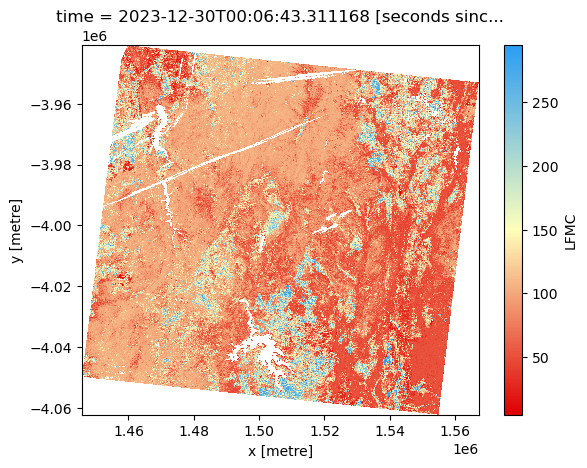

In [12]:
masked_data.LFMC.plot(cmap=cmap)

In [ ]:
masked_data.LFMC

In [23]:
FMC_data_int = FMC_data.astype('int16')
#make the data be a 16 bit int rather than a floating point. 

In [24]:

# save to file

write_cog(FMC_data_int.LFMC, fname=f'lfmc_output.tif')

PosixPath('lfmc_output.tif')